# Real-Time Explainable AI Platform for Employee Sentiment Analysis and Attrition Prediction Using Transformer Models

## 1. Import Required Libraries

In [66]:
# ==============================
# 1. Numerical Computation
# ==============================
import numpy as np

# ==============================
# 2. Data Manipulation
# ==============================
import pandas as pd

# ==============================
# 3. Data Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 4. Statistical Analysis
# ==============================
from scipy import stats
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr
)

# ==============================
# 5. Scikit-Learn Utilities
# ==============================
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score
)

# ==============================
# 6. Data Preprocessing
# ==============================
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Missing Value Imputation
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

# ==============================
# 7. Feature Selection
# ==============================
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    f_classif,
    mutual_info_classif
)

# ==============================
# 8. Machine Learning Models
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ==============================
# 9. Model Evaluation Metrics
# ==============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# ==============================
# 10. Class Imbalance Handling
# ==============================
from imblearn.over_sampling import (
    SMOTE,
    ADASYN,
    RandomOverSampler
)

from imblearn.under_sampling import RandomUnderSampler

# ==============================
# 11. Deep Learning (TensorFlow/Keras)
# ==============================
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Conv2D,
    MaxPooling2D,
    Flatten,
    LSTM,
    GRU
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

# ==============================
# 12. Explainable AI (XAI)
# ==============================
import shap
import lime
import lime.lime_tabular

# ==============================
# 13. Model Saving
# ==============================
import joblib
import pickle

# ==============================
# 14. Warning Suppression
# ==============================
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 15. Display Settings
# ==============================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Data Understanding

### Load Dataset

In [67]:
# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

### Display First 5 Records

In [68]:
# Display first 5 records
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### Display Last 5 Records

In [69]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


### Display Random Sample Records

In [70]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
967,40,No,Travel_Rarely,329,Research & Development,1,4,Life Sciences,1,1361,2,Male,88,3,1,Laboratory Technician,2,Married,2387,6762,3,Y,No,22,4,3,80,1,7,3,3,4,2,0,3
215,41,No,Travel_Rarely,896,Sales,6,3,Life Sciences,1,298,4,Female,75,3,3,Manager,4,Single,13591,14674,3,Y,Yes,18,3,3,80,0,16,3,3,1,0,0,0
441,42,No,Travel_Frequently,1474,Research & Development,5,2,Other,1,591,2,Male,97,3,1,Laboratory Technician,3,Married,2093,9260,4,Y,No,17,3,4,80,1,8,4,3,2,2,2,0
217,29,Yes,Travel_Rarely,992,Research & Development,1,3,Technical Degree,1,300,3,Male,85,3,1,Research Scientist,3,Single,2058,19757,0,Y,No,14,3,4,80,0,7,1,2,6,2,1,5
1267,34,No,Non-Travel,1375,Sales,10,3,Life Sciences,1,1774,4,Male,87,3,2,Sales Executive,3,Divorced,4001,12313,1,Y,Yes,14,3,3,80,1,15,3,3,15,14,0,7


### Dataset Shape

In [71]:
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (1470, 35)
Rows: 1470
Columns: 35


### Column Names

In [72]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


### Dataset Overview

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Initial Data Quality

#### Data Types

In [74]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

#### Missing Values

In [75]:
missing_values = df.isnull().sum()

In [76]:

missing_values[missing_values > 0]

Series([], dtype: int64)

#### Missing Value Percentage

In [77]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

Age                         0.0
Attrition                   0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtC

#### Duplicate Records

In [78]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


#### Unique Value Counts

In [79]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

#### Memory Usage

In [80]:
df.memory_usage(deep=True)

Index                         132
Age                         11760
Attrition                   75207
BusinessTravel              91798
DailyRate                   11760
Department                  96347
DistanceFromHome            11760
Education                   11760
EducationField              87514
EmployeeCount               11760
EmployeeNumber              11760
EnvironmentSatisfaction     11760
Gender                      79086
HourlyRate                  11760
JobInvolvement              11760
JobLevel                    11760
JobRole                     98594
JobSatisfaction             11760
MaritalStatus               82177
MonthlyIncome               11760
MonthlyRate                 11760
NumCompaniesWorked          11760
Over18                      73500
OverTime                    75386
PercentSalaryHike           11760
PerformanceRating           11760
RelationshipSatisfaction    11760
StandardHours               11760
StockOptionLevel            11760
TotalWorkingYe

In [81]:
print("Memory Usage:",
      round(df.memory_usage(deep=True).sum()/1024**2,2),
      "MB")

Memory Usage: 1.02 MB


### Separate Numerical and Categorical Features

In [82]:
numerical_features = df.select_dtypes(
    include=['int64','float64']
).columns

categorical_features = df.select_dtypes(
    include=['object','category']
).columns

In [83]:
print("Numerical Features:")
print(numerical_features)

Numerical Features:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [84]:
print("\nCategorical Features:")
print(categorical_features)


Categorical Features:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


### Data Quality Summary Table

In [85]:
quality_report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2),
    'Unique Values': df.nunique()
})

quality_report

,Data Type,Missing Values,Missing %,Unique Values
Age,int64,0,0.0,43
Attrition,object,0,0.0,2
BusinessTravel,object,0,0.0,3
DailyRate,int64,0,0.0,886
Department,object,0,0.0,3
DistanceFromHome,int64,0,0.0,29
Education,int64,0,0.0,5
EducationField,object,0,0.0,6
EmployeeCount,int64,0,0.0,1
EmployeeNumber,int64,0,0.0,1470


## 3. Descriptive Statistical Analysis

### Statistical Summary

In [86]:
# Statistical Summary
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Skewness

In [87]:
skewness = df.skew(numeric_only=True)

print(skewness)

Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EmployeeCount               0.000000
EmployeeNumber              0.016574
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.369817
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StandardHours               0.000000
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.764529
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: float64


### Kurtosis

In [88]:
kurtosis = df.kurtosis(numeric_only=True)

print(kurtosis)

Age                        -0.404145
DailyRate                  -1.203823
DistanceFromHome           -0.224833
Education                  -0.559115
EmployeeCount               0.000000
EmployeeNumber             -1.223179
EnvironmentSatisfaction    -1.202521
HourlyRate                 -1.196398
JobInvolvement              0.270999
JobLevel                    0.399152
JobSatisfaction            -1.222193
MonthlyIncome               1.005233
MonthlyRate                -1.214956
NumCompaniesWorked          0.010214
PercentSalaryHike          -0.300598
PerformanceRating           1.695939
RelationshipSatisfaction   -1.184814
StandardHours               0.000000
StockOptionLevel            0.364634
TotalWorkingYears           0.918270
TrainingTimesLastYear       0.494993
WorkLifeBalance             0.419460
YearsAtCompany              3.935509
YearsInCurrentRole          0.477421
YearsSinceLastPromotion     3.612673
YearsWithCurrManager        0.171058
dtype: float64


### Correlation Matrix

In [89]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.003634,0.001904,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.022704,0.000473,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.027110,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.011111,-0.024539,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,-0.046247,-0.014829,0.012648,-0.001251,-0.012944,-0.020359,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,-0.031701,-0.029548,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.015297,0.022157,-0.009062,-0.002172,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.017205,-0.029071,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,-0.034730,-0.021222,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


### Target Variable Summary (Employee Attrition)

In [90]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

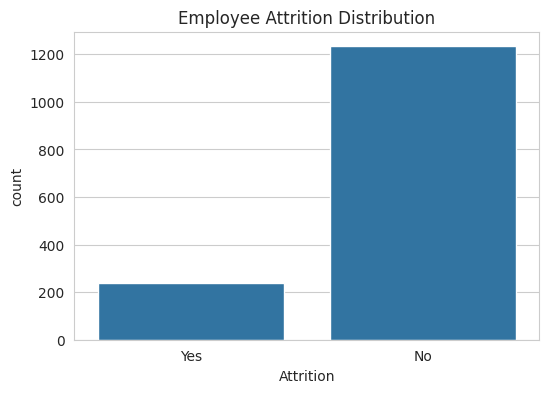

In [91]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Attrition',
    data=df
)

plt.title('Employee Attrition Distribution')
plt.show()

### Features to Remove Before Modeling

In [92]:
df[['EmployeeCount',
    'StandardHours',
    'Over18',
    'EmployeeNumber']].nunique()

EmployeeCount        1
StandardHours        1
Over18               1
EmployeeNumber    1470
dtype: int64

In [93]:
df.drop(
    columns=[
        'EmployeeCount',
        'StandardHours',
        'Over18',
        'EmployeeNumber'
    ],
    inplace=True
)

In [94]:
df.shape

(1470, 31)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

## 4. Exploratory Data Analysis (EDA)

### Numerical Features

In [96]:
numerical_features = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'Education',
    'EnvironmentSatisfaction',
    'HourlyRate',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'WorkLifeBalance',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

#### Distribution Plots (Histograms)

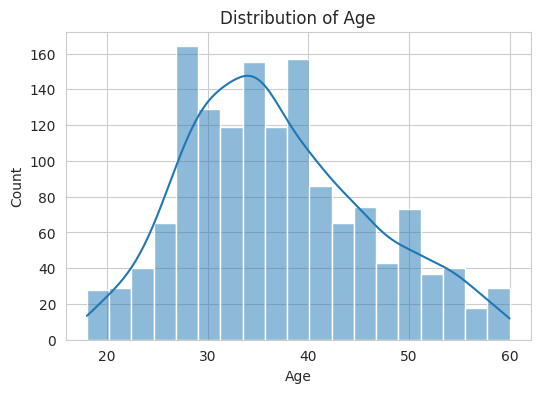

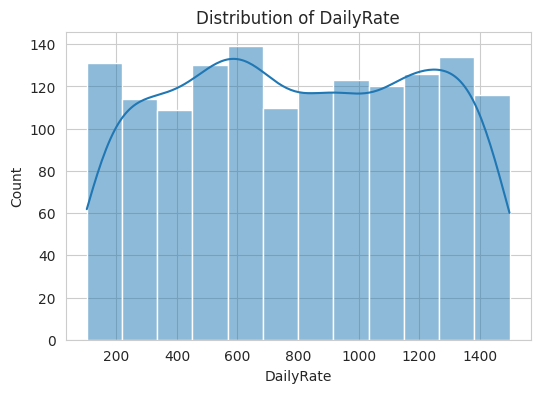

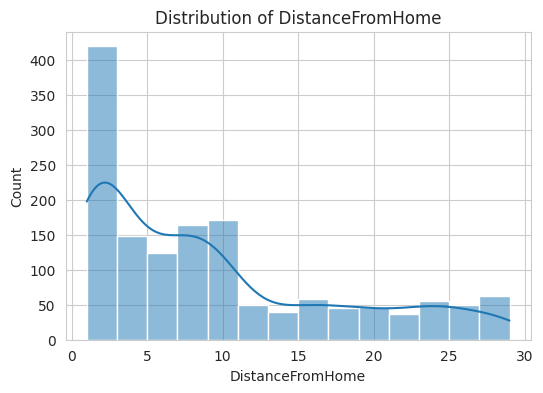

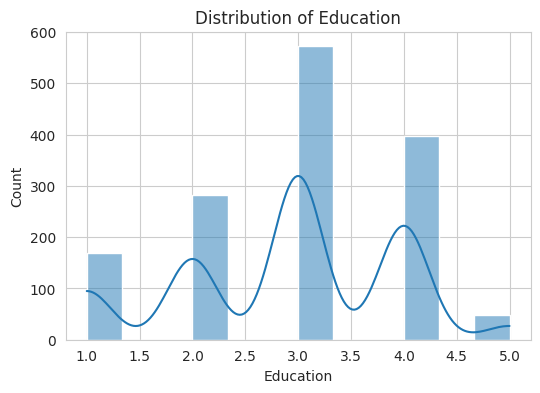

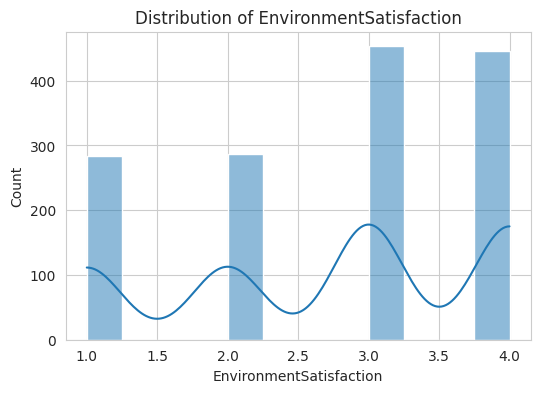

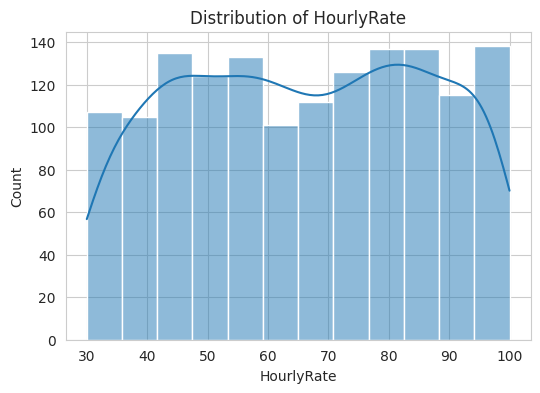

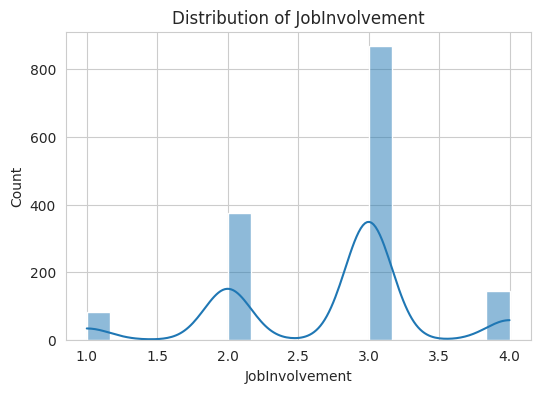

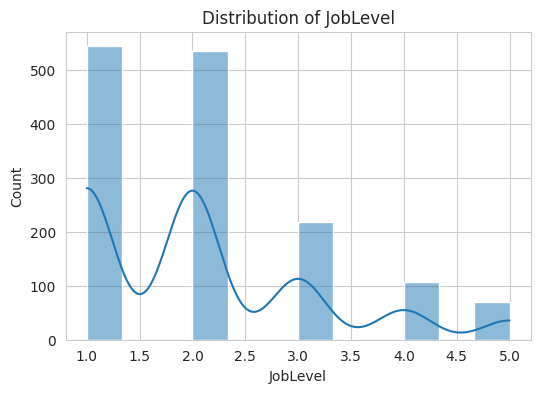

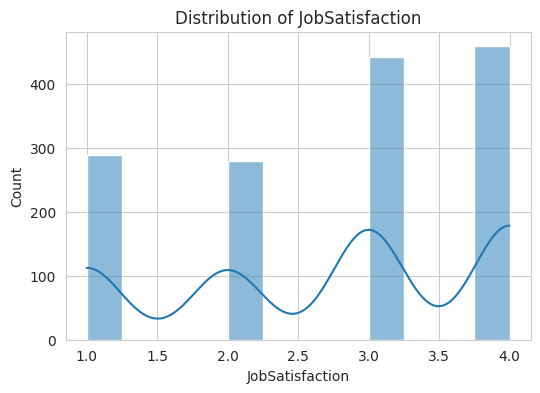

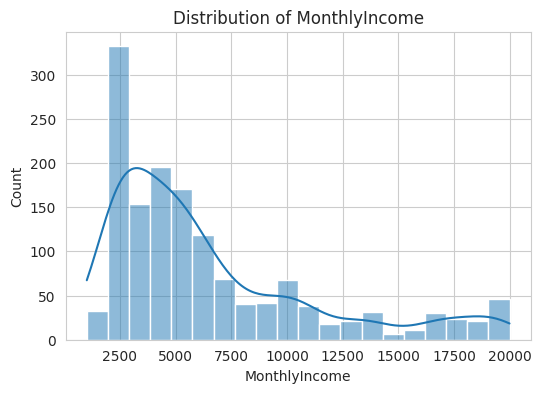

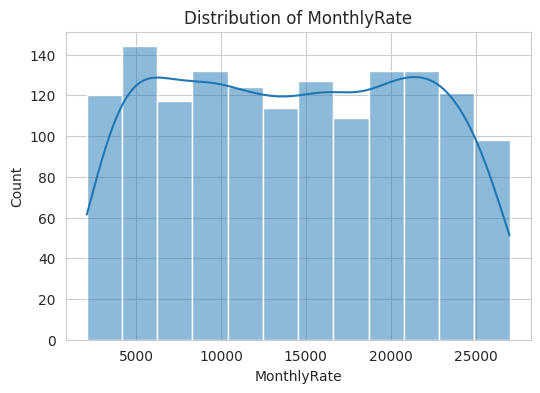

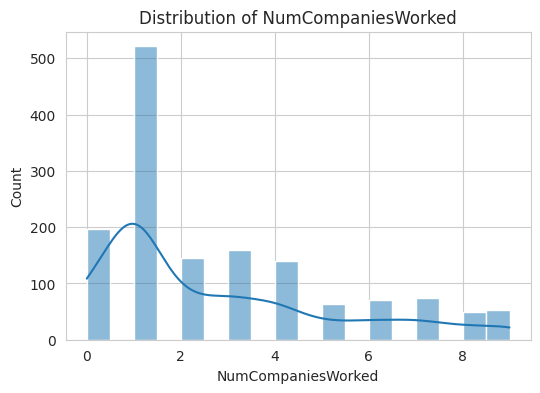

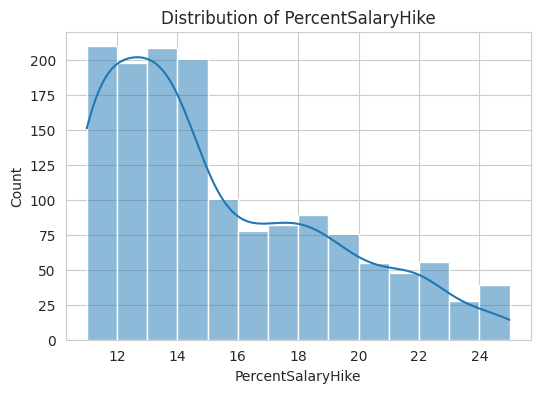

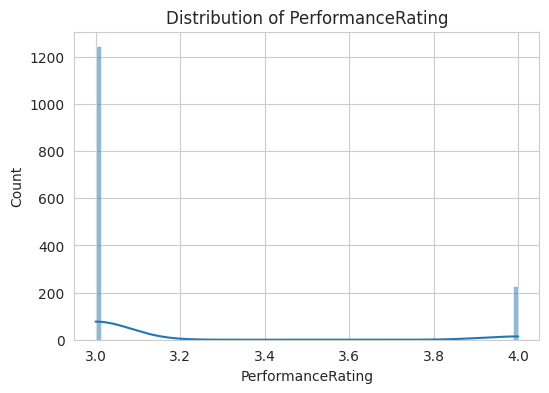

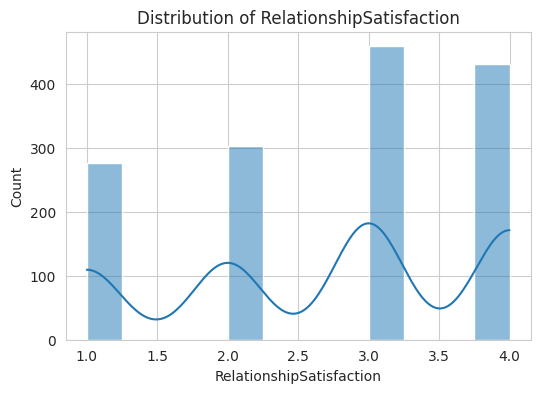

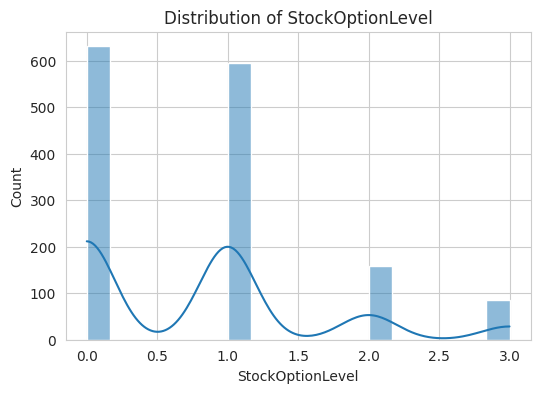

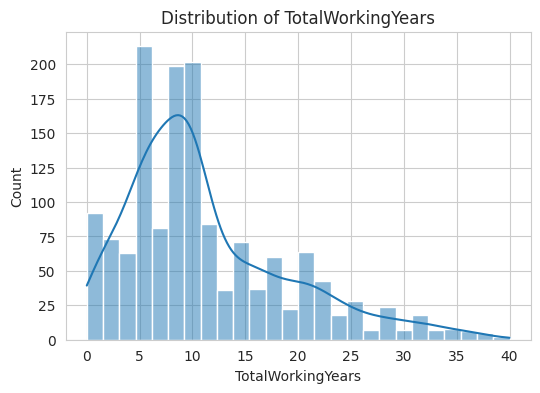

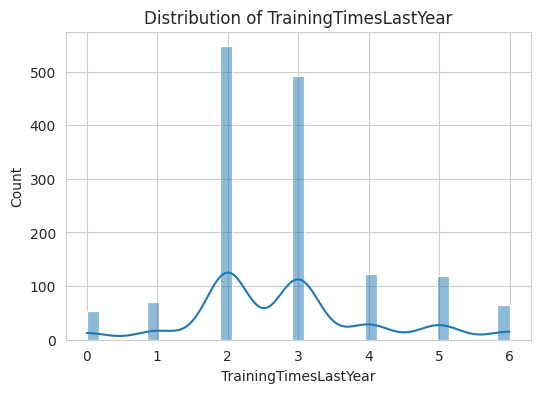

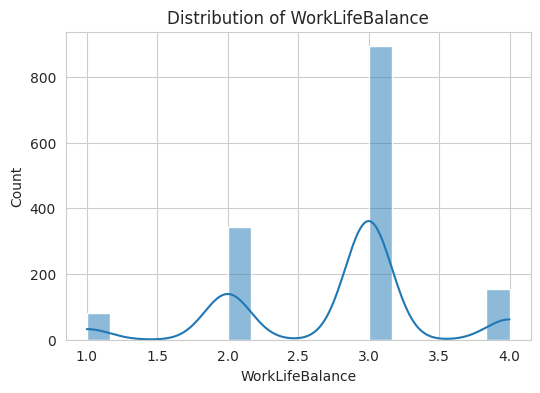

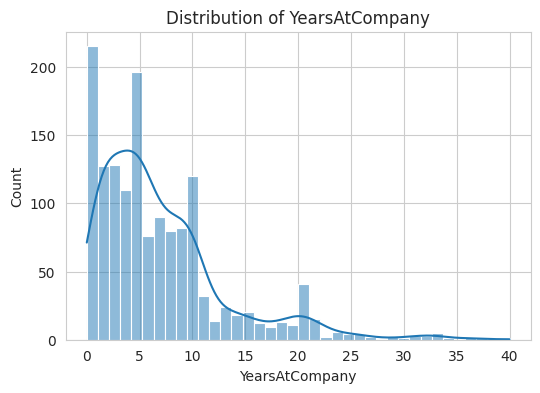

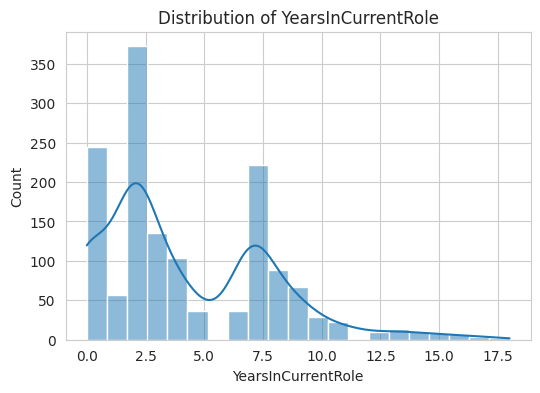

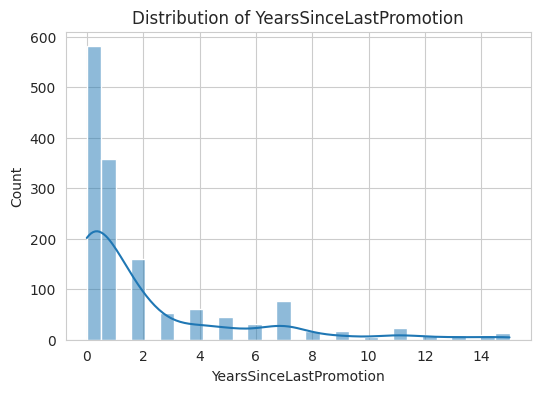

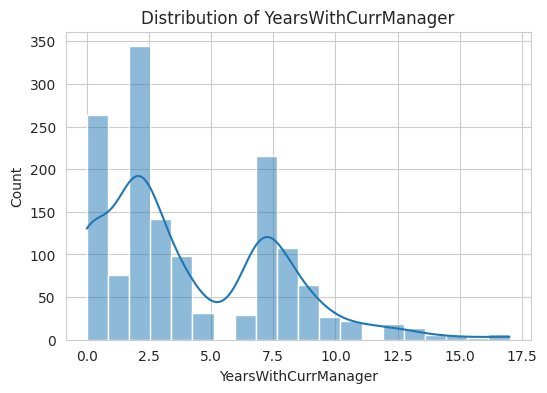

In [97]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#### Boxplots

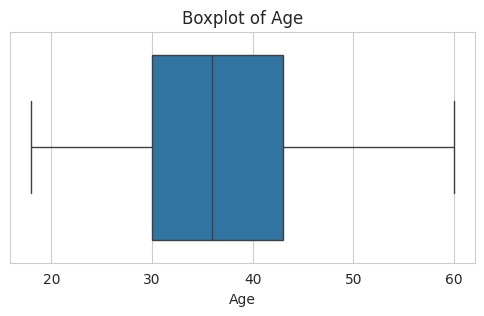

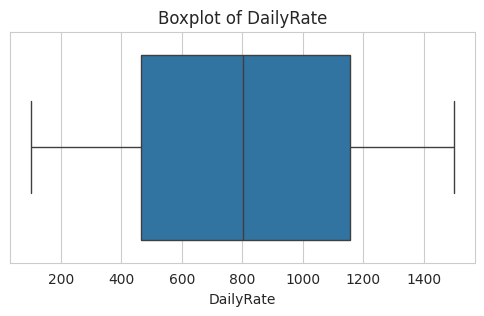

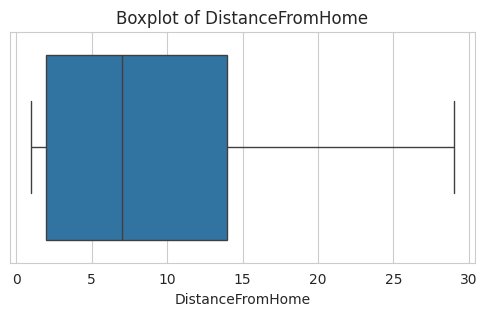

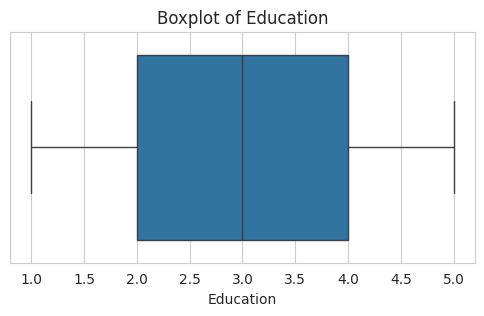

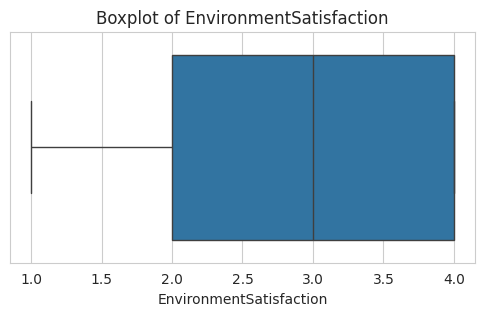

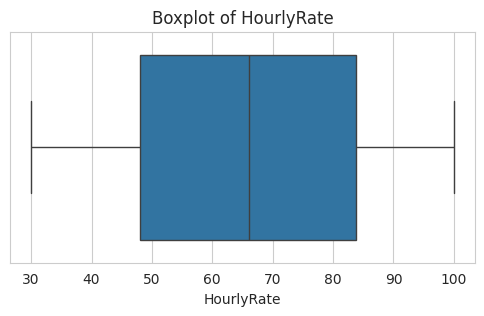

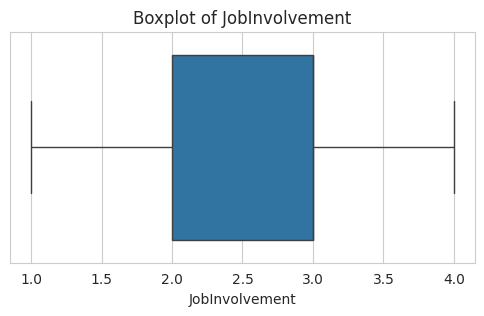

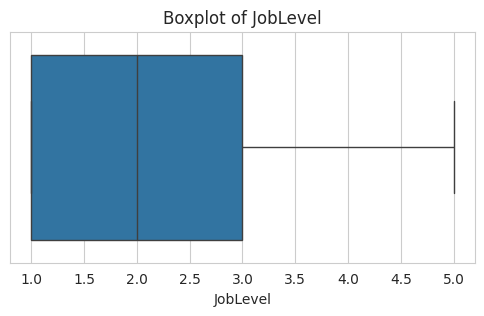

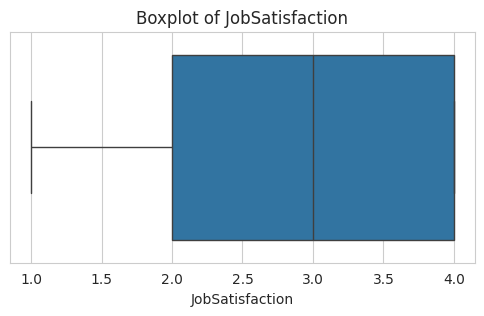

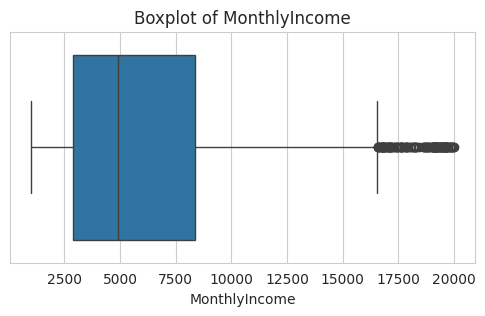

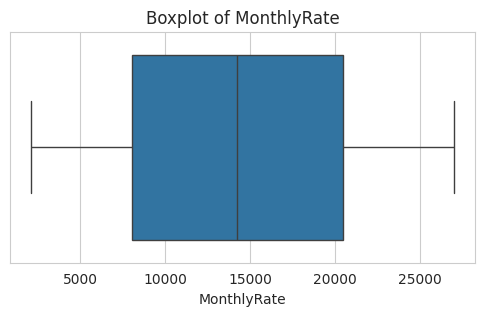

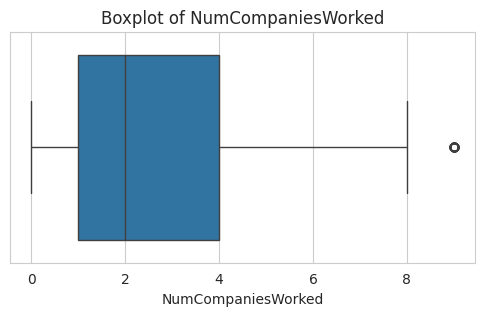

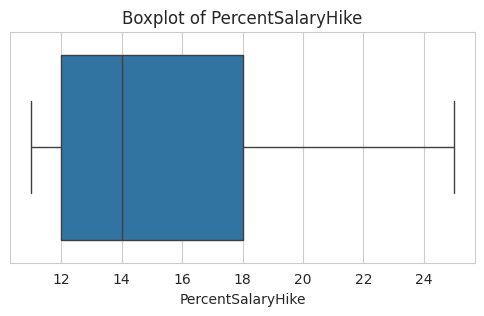

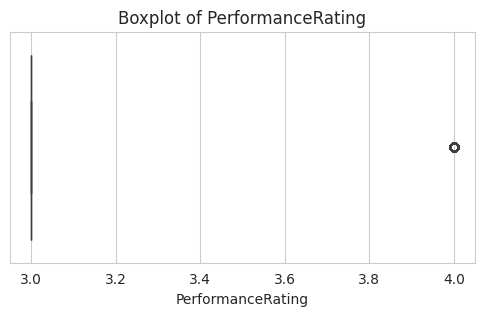

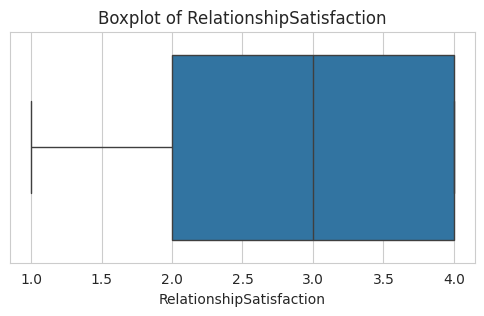

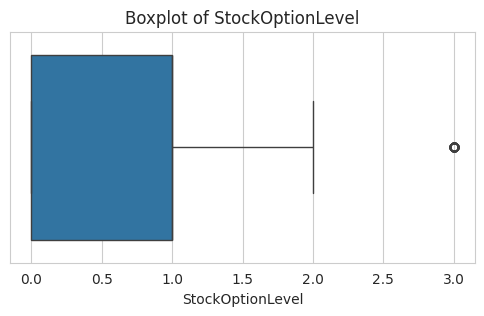

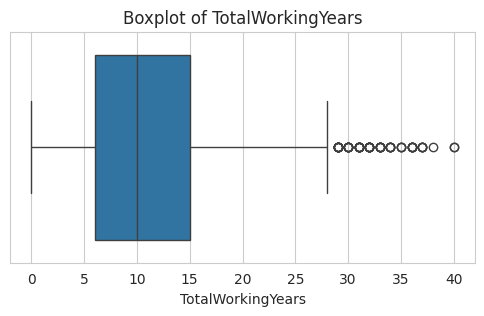

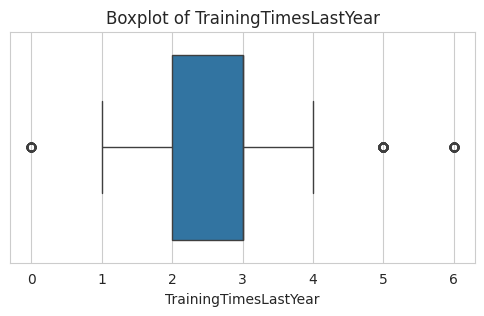

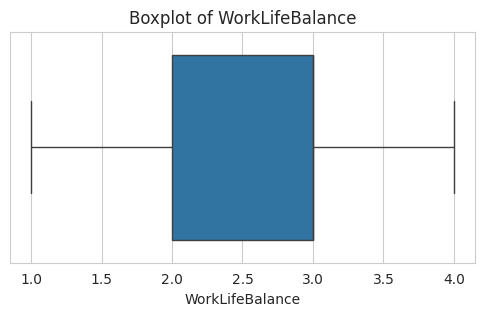

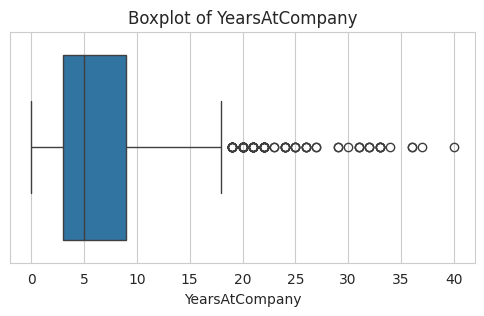

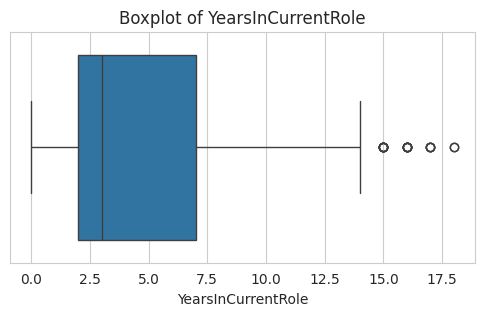

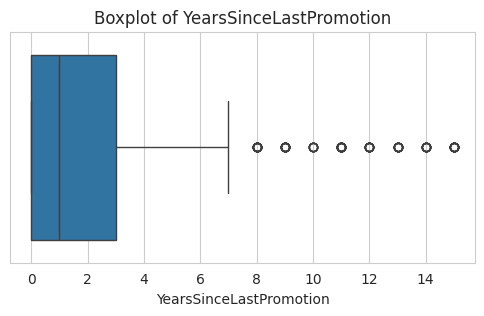

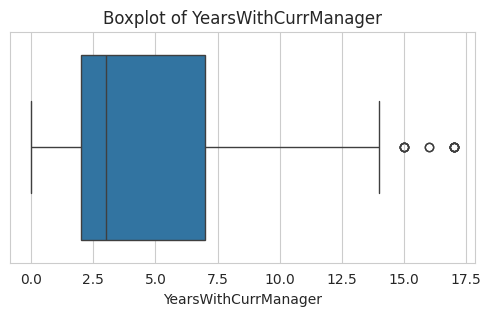

In [98]:
for col in numerical_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Categorical Features

In [99]:
categorical_features = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime',
    'Attrition'
]

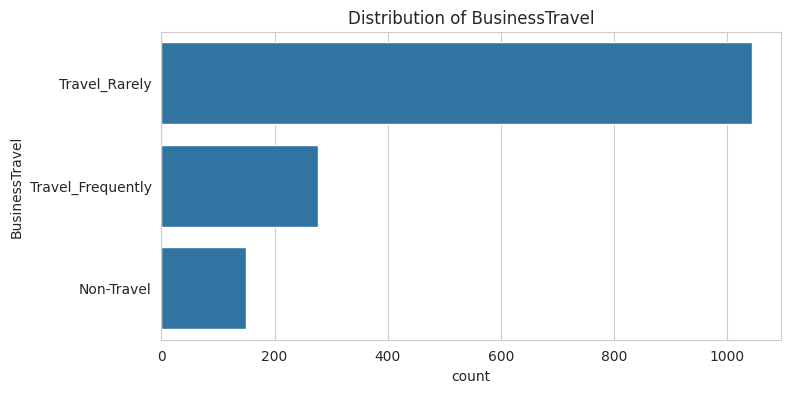

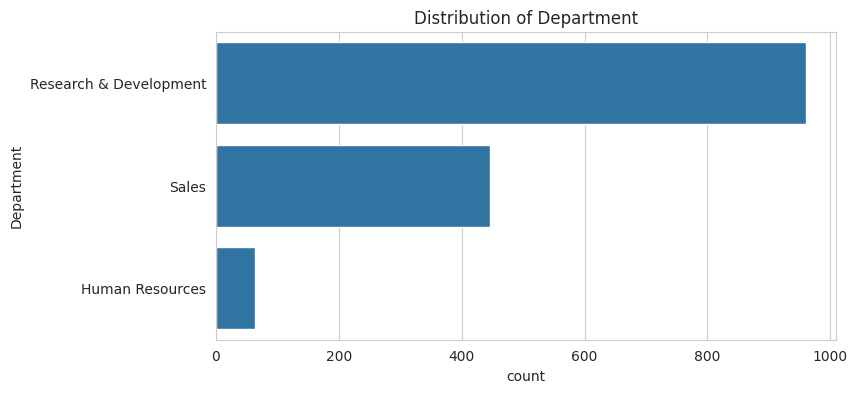

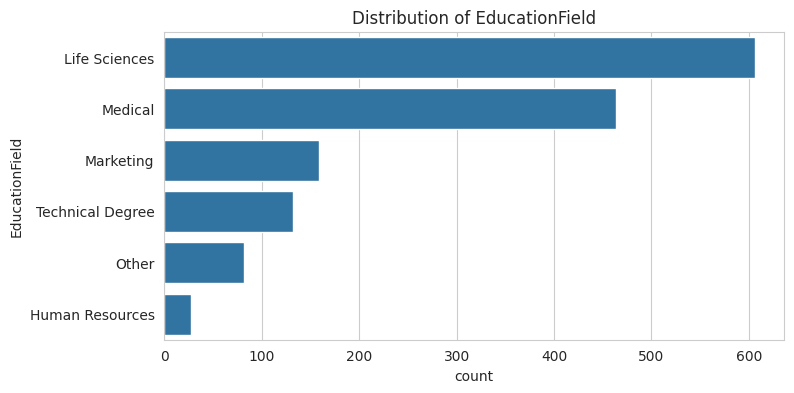

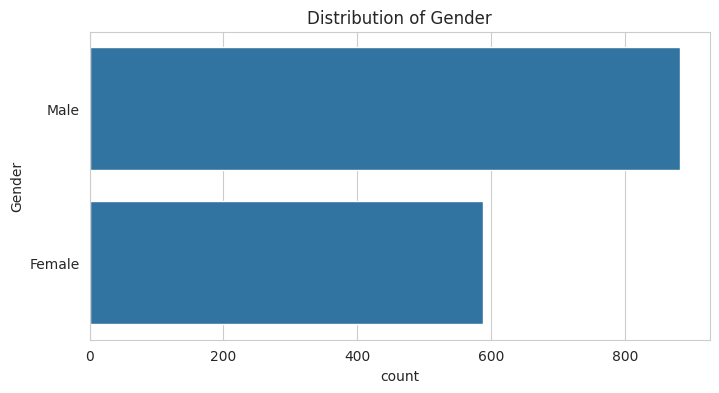

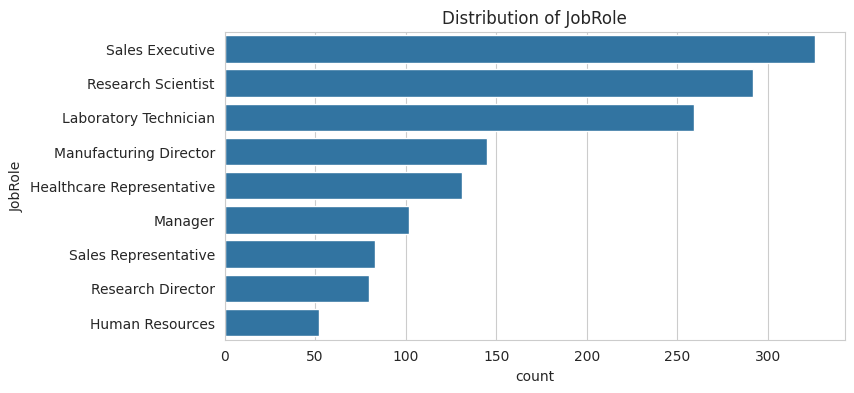

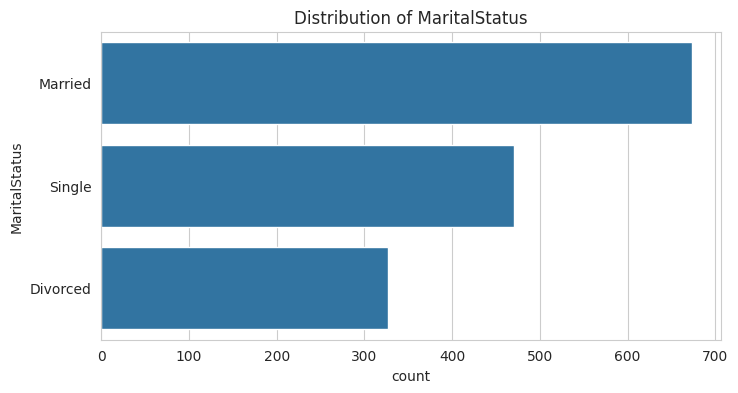

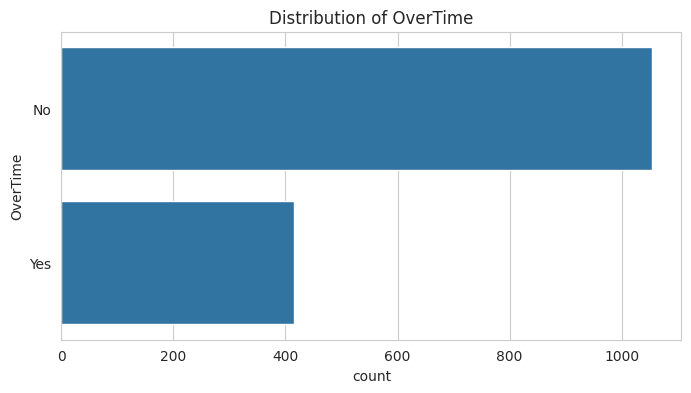

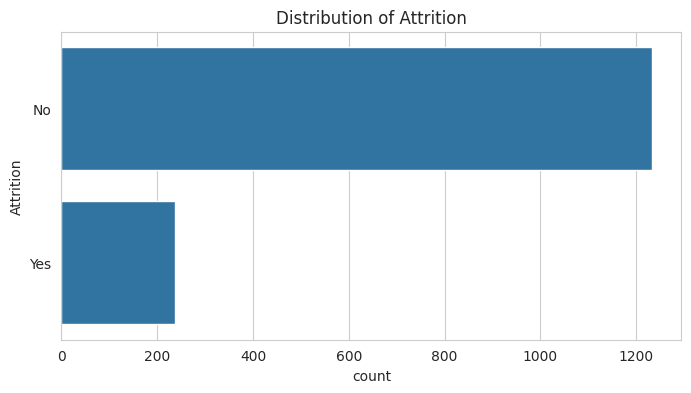

In [100]:
for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col,data=df,order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

## 5. Bivariate Analysis (Feature vs Attrition)

### Monthly Income vs Attrition

> *Do lower-paid employees leave more often?*

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

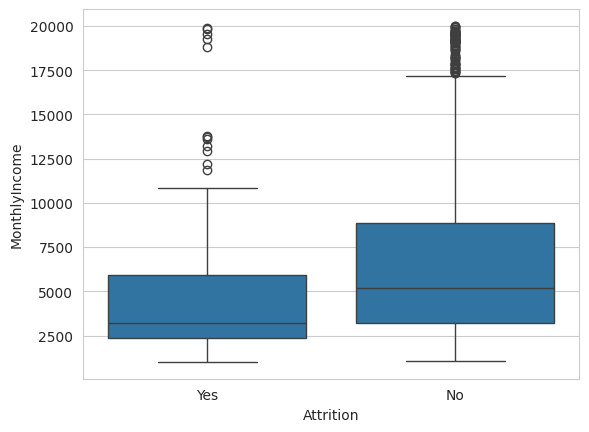

In [101]:
sns.boxplot(x='Attrition',
            y='MonthlyIncome',
            data=df)

### Age vs Attrition

> *Are younger employees more likely to leave?*

<Axes: xlabel='Attrition', ylabel='Age'>

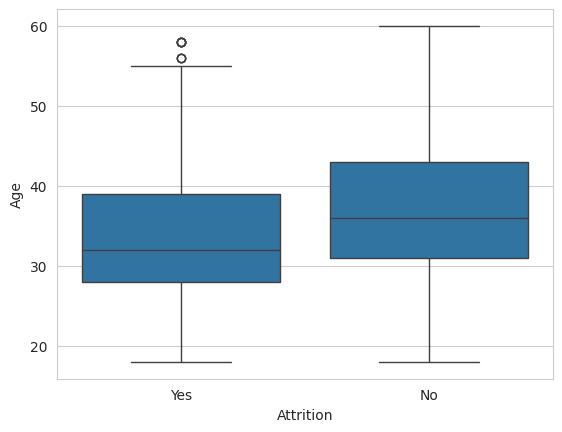

In [102]:
sns.boxplot(x='Attrition',
            y='Age',
            data=df)

### Total Working Years vs Attrition

> *Do less experienced employees leave more?*

<Axes: xlabel='Attrition', ylabel='TotalWorkingYears'>

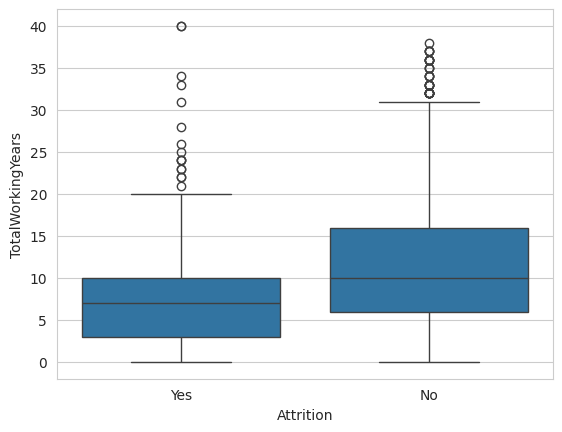

In [103]:
sns.boxplot(x='Attrition',
            y='TotalWorkingYears',
            data=df)

### Years At Company vs Attrition

> *Does attrition occur early in employment?*

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

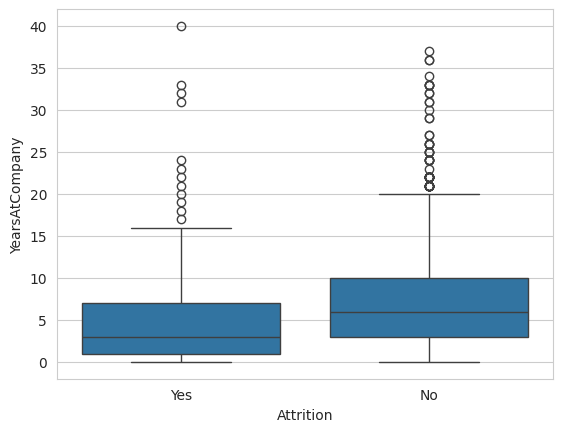

In [104]:
sns.boxplot(x='Attrition',
            y='YearsAtCompany',
            data=df)

### Distance From Home vs Attrition

> *Does commute distance impact attrition?*

<Axes: xlabel='Attrition', ylabel='DistanceFromHome'>

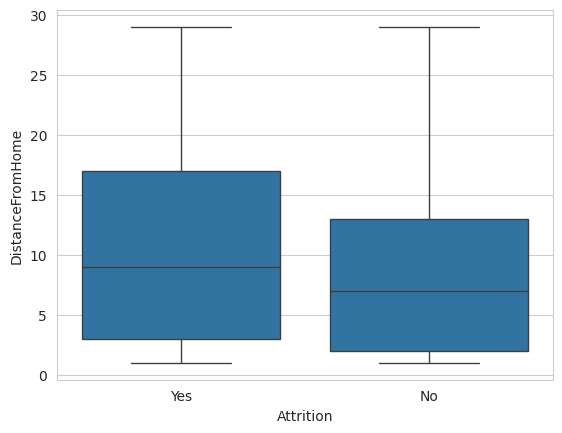

In [105]:
sns.boxplot(x='Attrition',
            y='DistanceFromHome',
            data=df)

### Job Satisfaction vs Attrition

> *Are dissatisfied employees leaving?*

<Axes: xlabel='Attrition', ylabel='JobSatisfaction'>

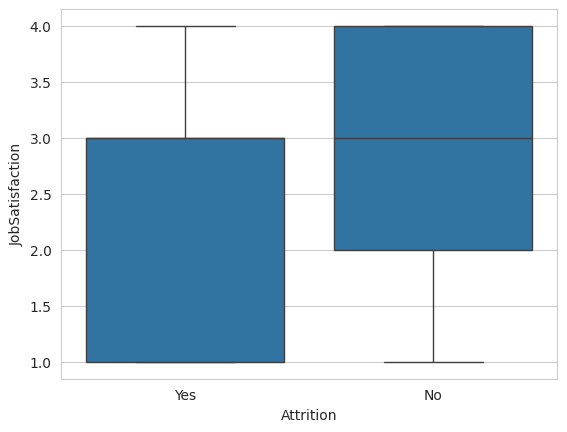

In [106]:
sns.boxplot(x='Attrition',
            y='JobSatisfaction',
            data=df)

### Work Life Balance vs Attrition

> *Is poor work-life balance causing attrition?*

<Axes: xlabel='Attrition', ylabel='WorkLifeBalance'>

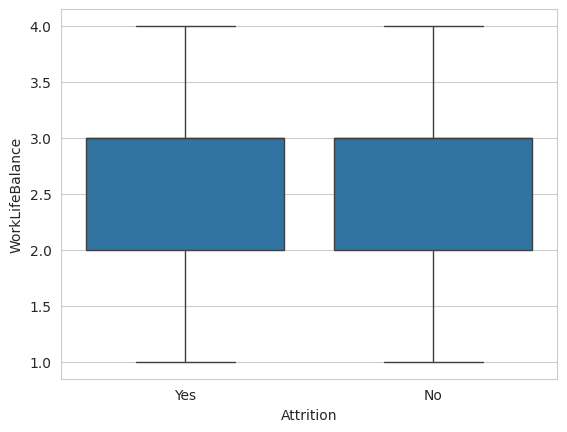

In [107]:
sns.boxplot(x='Attrition',
            y='WorkLifeBalance',
            data=df)

### Environment Satisfaction vs Attrition

> *Does workplace environment affect retention?*

<Axes: xlabel='Attrition', ylabel='EnvironmentSatisfaction'>

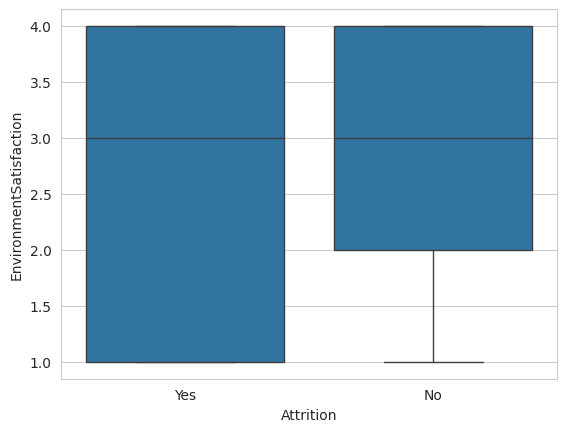

In [108]:
sns.boxplot(x='Attrition',
            y='EnvironmentSatisfaction',
            data=df)

## 6. Best Categorical vs Attrition Combinations

### Overtime vs Attrition

<Axes: xlabel='OverTime', ylabel='count'>

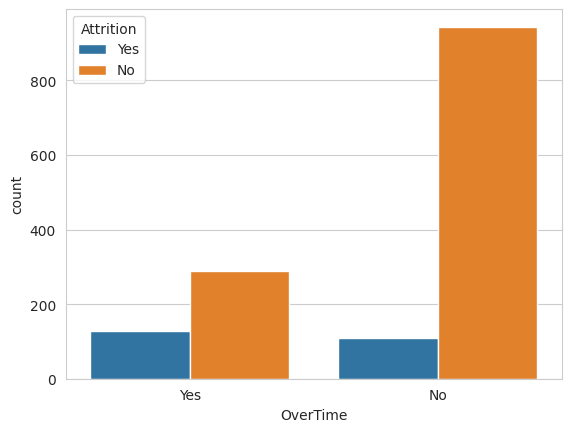

In [109]:
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)

### Job Role vs Attrition

<Axes: xlabel='count', ylabel='JobRole'>

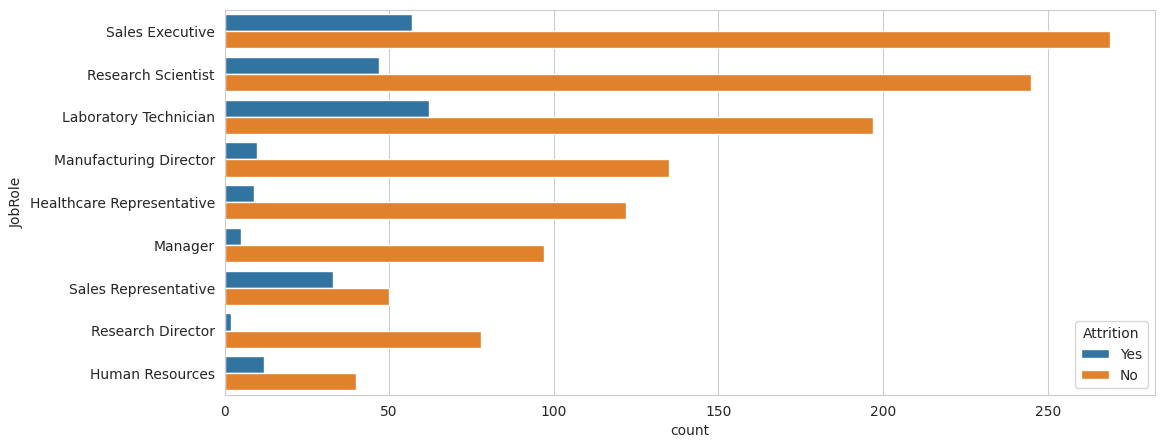

In [110]:
plt.figure(figsize=(12,5))

sns.countplot(
    y='JobRole',
    hue='Attrition',
    data=df
)

### Department vs Attrition

<Axes: xlabel='Department', ylabel='count'>

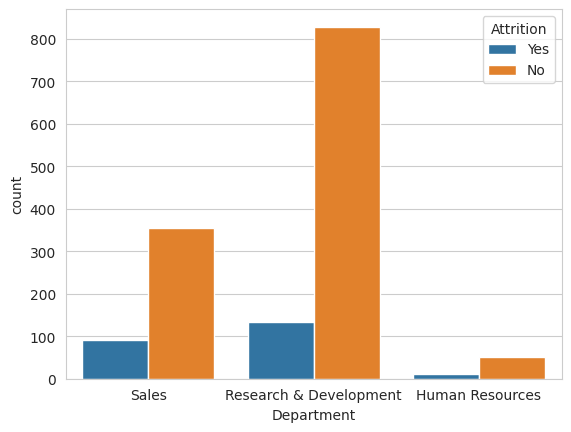

In [111]:
sns.countplot(
    x='Department',
    hue='Attrition',
    data=df
)

### Marital Status vs Attrition

<Axes: xlabel='MaritalStatus', ylabel='count'>

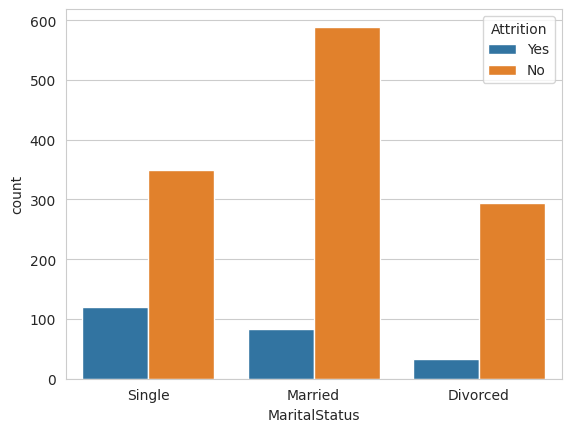

In [112]:
sns.countplot(
    x='MaritalStatus',
    hue='Attrition',
    data=df
)

### Business Travel vs Attrition

<Axes: xlabel='BusinessTravel', ylabel='count'>

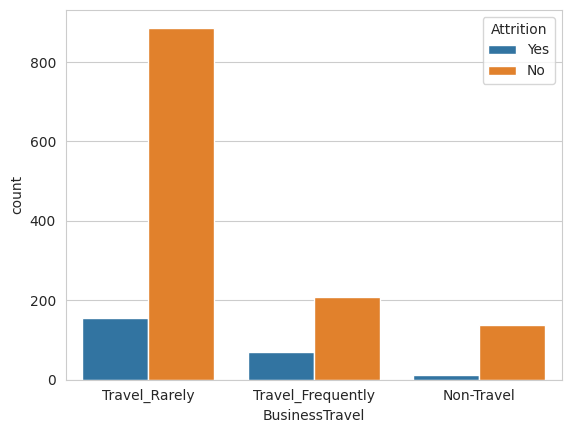

In [113]:
sns.countplot(
    x='BusinessTravel',
    hue='Attrition',
    data=df
)

### Education Field vs Attrition

<Axes: xlabel='count', ylabel='EducationField'>

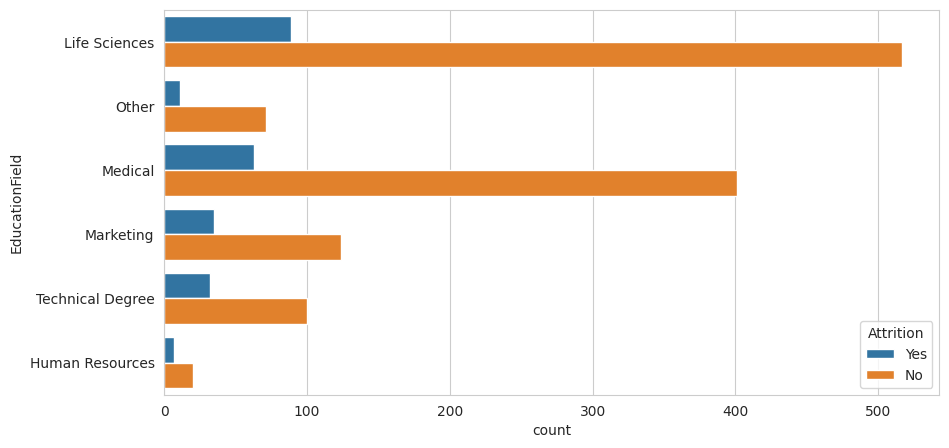

In [114]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='EducationField',
    hue='Attrition',
    data=df
)

## 7. Multivariate Analysis

### Correlation Heatmap

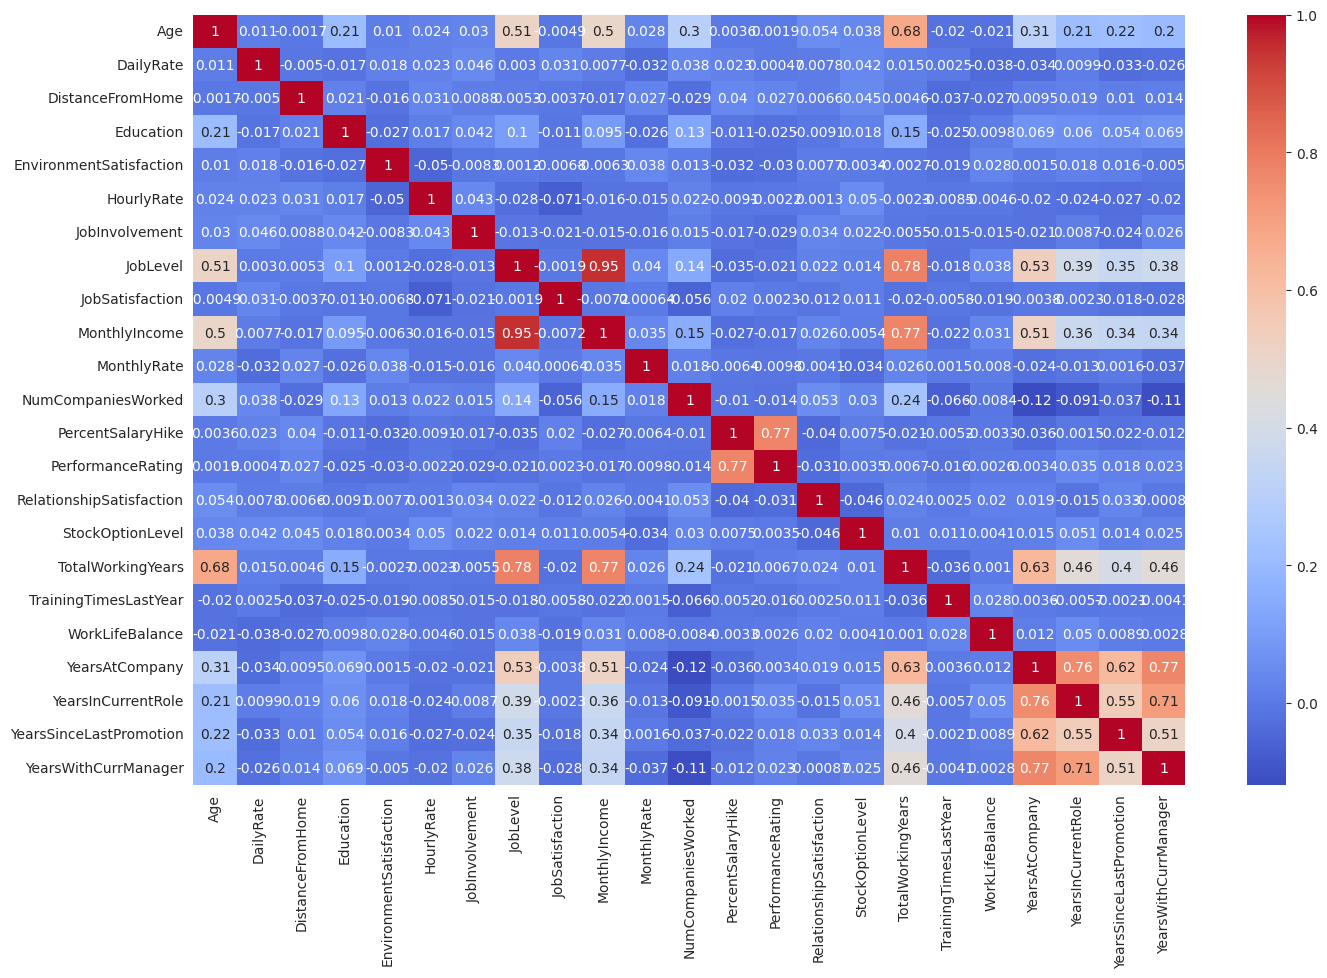

In [115]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

### Top Features Correlated With Income

In [116]:
corr = df.corr(numeric_only=True)

corr['MonthlyIncome'].sort_values(ascending=False)

MonthlyIncome               1.000000
JobLevel                    0.950300
TotalWorkingYears           0.772893
YearsAtCompany              0.514285
Age                         0.497855
YearsInCurrentRole          0.363818
YearsSinceLastPromotion     0.344978
YearsWithCurrManager        0.344079
NumCompaniesWorked          0.149515
Education                   0.094961
MonthlyRate                 0.034814
WorkLifeBalance             0.030683
RelationshipSatisfaction    0.025873
DailyRate                   0.007707
StockOptionLevel            0.005408
EnvironmentSatisfaction    -0.006259
JobSatisfaction            -0.007157
JobInvolvement             -0.015271
HourlyRate                 -0.015794
DistanceFromHome           -0.017014
PerformanceRating          -0.017120
TrainingTimesLastYear      -0.021736
PercentSalaryHike          -0.027269
Name: MonthlyIncome, dtype: float64

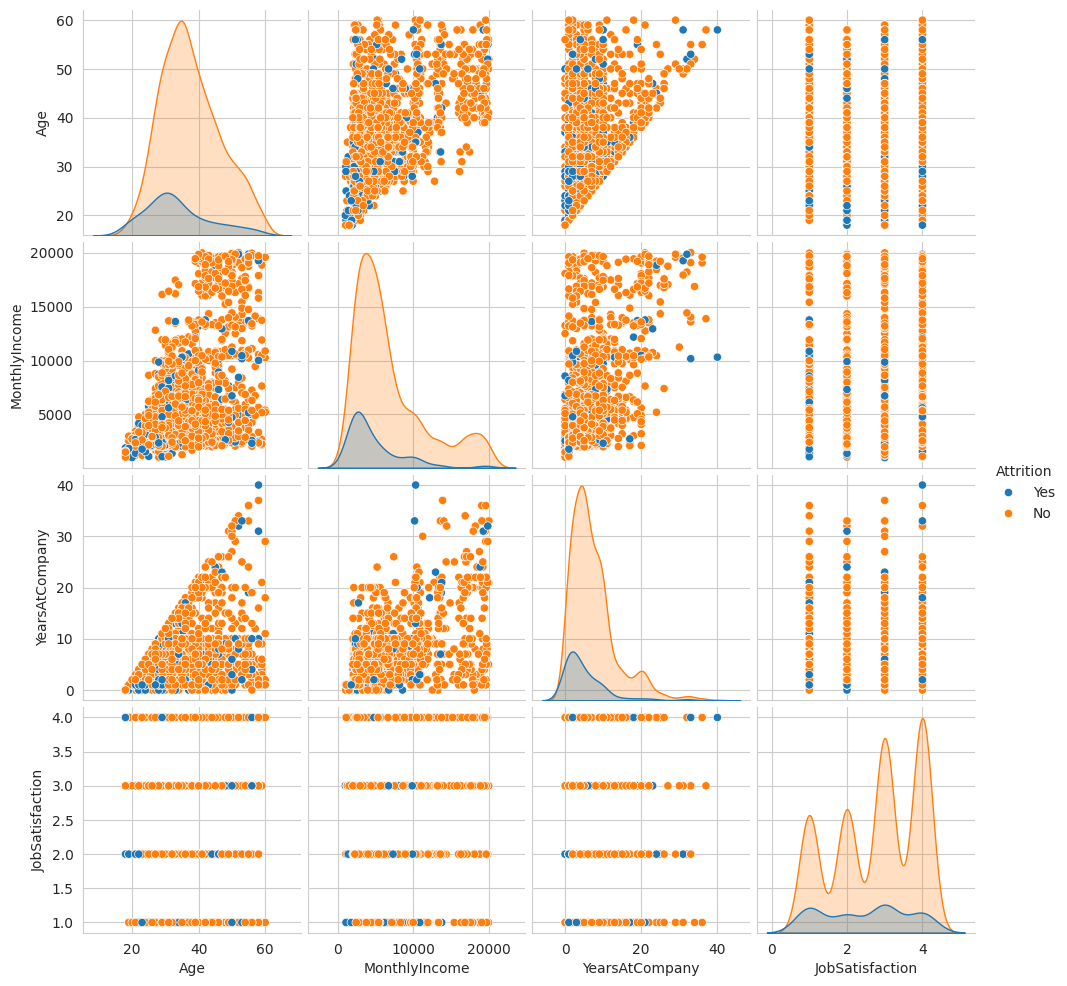

In [117]:
selected = [
    'Age',
    'MonthlyIncome',
    'YearsAtCompany',
    'JobSatisfaction'
]

sns.pairplot(
    df[selected + ['Attrition']],
    hue='Attrition'
)

### Highest-Value 3-Way Analysis: Overtime + Job Satisfaction + Attrition

> *Do employees working overtime leave even when satisfied?*

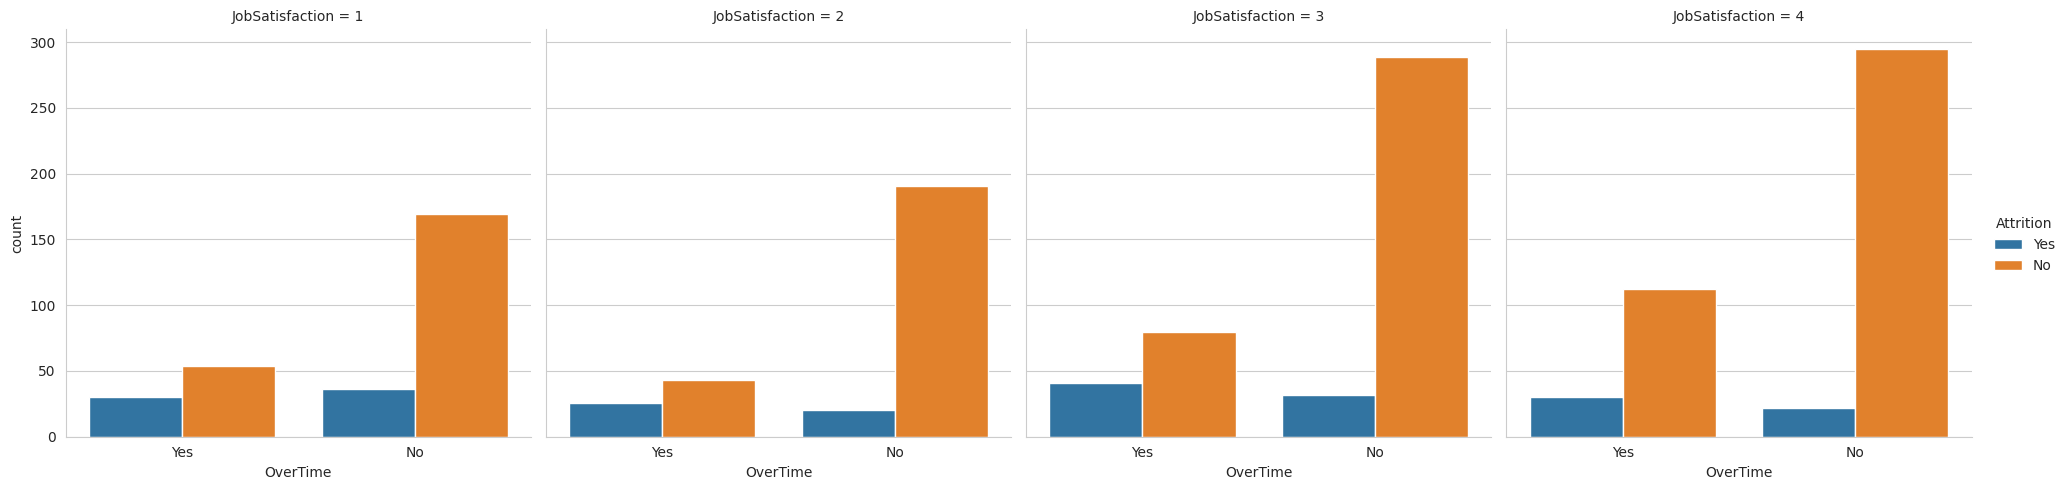

In [118]:
sns.catplot(
    x='OverTime',
    hue='Attrition',
    col='JobSatisfaction',
    kind='count',
    data=df
)

### Department + Overtime + Attrition

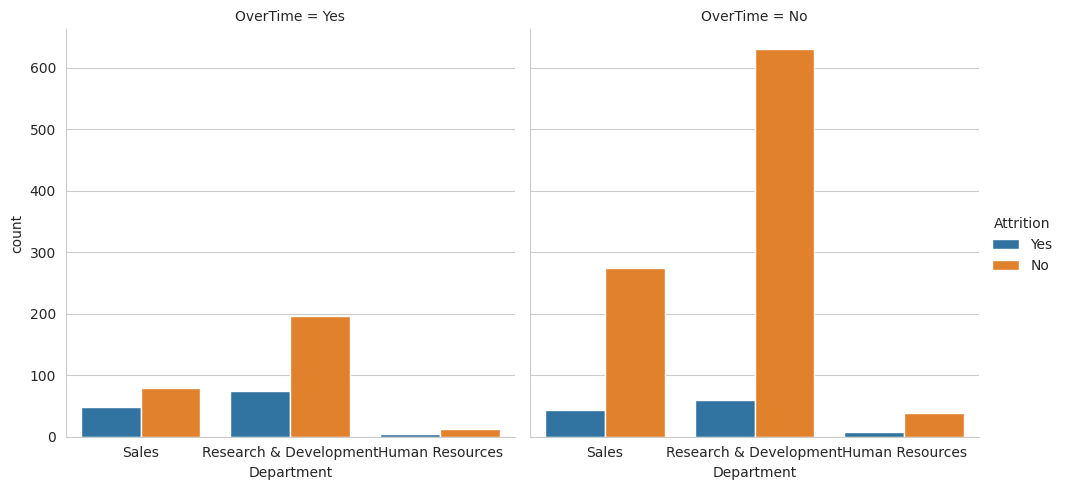

In [119]:
sns.catplot(
    x='Department',
    hue='Attrition',
    col='OverTime',
    kind='count',
    data=df
)

### Job Role + Overtime + Attrition

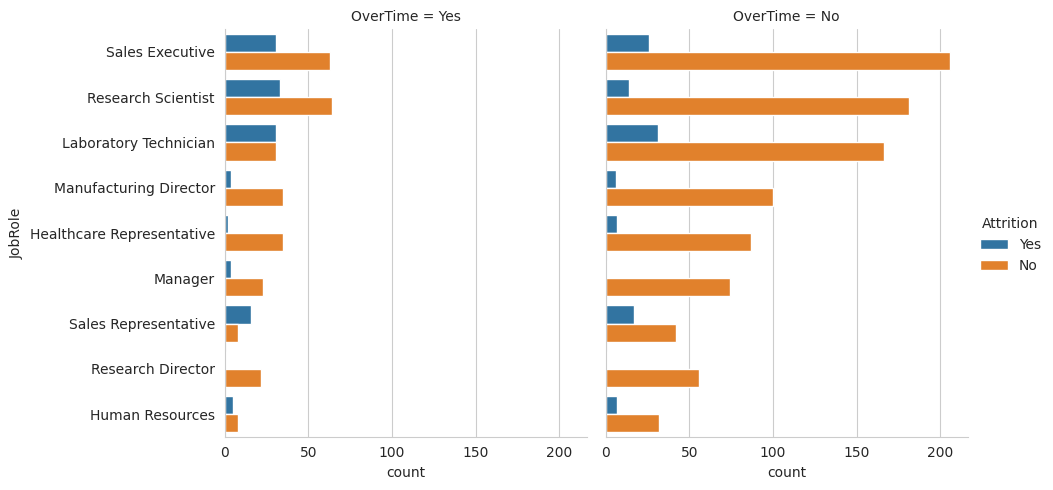

In [120]:
sns.catplot(
    y='JobRole',
    hue='Attrition',
    col='OverTime',
    kind='count',
    data=df,
    height=5
)

## 8. Data Preprocessing

### Check Missing Values

In [121]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

### Check Duplicates

In [122]:
df.duplicated().sum()

np.int64(0)

### Outlier Detection & Treatment

In [123]:
outlier_cols = [
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'DistanceFromHome',
    'Age'
]

#### IQR Method

In [124]:
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

In [125]:
for col in outlier_cols:

    outliers = detect_outliers_iqr(df,col)

    print(col, len(outliers))

MonthlyIncome 114
TotalWorkingYears 63
YearsAtCompany 104
DistanceFromHome 0
Age 0


# H₀ (Null Hypothesis): The column has no significant relationship with Attrition.
# H₁ (Alternative Hypothesis): The column has a significant relationship with Attrition.
# If p-value < 0.05 → Reject H₀ (feature is significant).
# If p-value ≥ 0.05 → Fail to reject H₀ (feature is not significant).

# Reject H₀	----->    Evidence supports H₁
# Fail to Reject H₀	--------> Not enough evidence to support H₁

# Separate Numerical and Categorical Columns

In [126]:
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Categorical Columns: Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')


# Numerical Columns → Independent T-Test

In [127]:
from scipy.stats import ttest_ind

for col in num_cols:
    yes = df[df['Attrition']=='Yes'][col]
    no = df[df['Attrition']=='No'][col]

    stat, p = ttest_ind(yes, no)

    print(f"\nColumn: {col}")
    print("P-value:", round(p,4))

    if p < 0.05:
        print("Reject H0 → Significant relationship with Attrition")
    else:
        print("Fail to Reject H0 → No significant relationship")


Column: Age
P-value: 0.0
Reject H0 → Significant relationship with Attrition

Column: DailyRate
P-value: 0.0299
Reject H0 → Significant relationship with Attrition

Column: DistanceFromHome
P-value: 0.0028
Reject H0 → Significant relationship with Attrition

Column: Education
P-value: 0.2293
Fail to Reject H0 → No significant relationship

Column: EnvironmentSatisfaction
P-value: 0.0001
Reject H0 → Significant relationship with Attrition

Column: HourlyRate
P-value: 0.7931
Fail to Reject H0 → No significant relationship

Column: JobInvolvement
P-value: 0.0
Reject H0 → Significant relationship with Attrition

Column: JobLevel
P-value: 0.0
Reject H0 → Significant relationship with Attrition

Column: JobSatisfaction
P-value: 0.0001
Reject H0 → Significant relationship with Attrition

Column: MonthlyIncome
P-value: 0.0
Reject H0 → Significant relationship with Attrition

Column: MonthlyRate
P-value: 0.5611
Fail to Reject H0 → No significant relationship

Column: NumCompaniesWorked
P-value

In [128]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    
    if col != 'Attrition':
        
        table = pd.crosstab(df[col], df['Attrition'])

        chi2, p, dof, exp = chi2_contingency(table)

        print(f"\nColumn: {col}")
        print("P-value:", round(p,4))

        if p < 0.05:
            print("Reject H0 → Significant relationship")
        else:
            print("Fail to Reject H0 → No significant relationship")


Column: BusinessTravel
P-value: 0.0
Reject H0 → Significant relationship

Column: Department
P-value: 0.0045
Reject H0 → Significant relationship

Column: EducationField
P-value: 0.0068
Reject H0 → Significant relationship

Column: Gender
P-value: 0.2906
Fail to Reject H0 → No significant relationship

Column: JobRole
P-value: 0.0
Reject H0 → Significant relationship

Column: MaritalStatus
P-value: 0.0
Reject H0 → Significant relationship

Column: OverTime
P-value: 0.0
Reject H0 → Significant relationship


In [129]:
from scipy.stats import ttest_ind, chi2_contingency
import pandas as pd

results = []

for col in df.columns:
    
    if col == 'Attrition':
        continue

    if df[col].dtype == 'object':

        table = pd.crosstab(df[col], df['Attrition'])

        stat, p, dof, exp = chi2_contingency(table)

    else:

        yes = df[df['Attrition']=='Yes'][col]
        no = df[df['Attrition']=='No'][col]

        stat, p = ttest_ind(yes, no)

    decision = "Reject H0" if p < 0.05 else "Fail to Reject H0"

    results.append([col, round(p,4), decision])

summary = pd.DataFrame(
results,
columns=['Feature','P_Value','Decision']
)

print(summary.sort_values('P_Value'))

                     Feature  P_Value           Decision
0                        Age   0.0000          Reject H0
1             BusinessTravel   0.0000          Reject H0
10            JobInvolvement   0.0000          Reject H0
15             MonthlyIncome   0.0000          Reject H0
12                   JobRole   0.0000          Reject H0
14             MaritalStatus   0.0000          Reject H0
11                  JobLevel   0.0000          Reject H0
18                  OverTime   0.0000          Reject H0
27        YearsInCurrentRole   0.0000          Reject H0
22          StockOptionLevel   0.0000          Reject H0
29      YearsWithCurrManager   0.0000          Reject H0
26            YearsAtCompany   0.0000          Reject H0
23         TotalWorkingYears   0.0000          Reject H0
7    EnvironmentSatisfaction   0.0001          Reject H0
13           JobSatisfaction   0.0001          Reject H0
4           DistanceFromHome   0.0028          Reject H0
3                 Department   

Final Interpretation

Reject H₀ = The feature is significantly related to employee attrition.

Fail to Reject H₀ = No strong statistical evidence that the feature affects attrition.

Features with the lowest p-values are usually the strongest drivers of employee attrition and should be highlighted in your HR analytics report.